In [1]:
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statannotations.Annotator import Annotator

In [2]:
from sklearn.metrics import roc_auc_score, roc_curve


def plot_roc_curve(predictions, filename):
    roc_auc = roc_auc_score(predictions["targets"], predictions["predictions"])
    # print(f"ROC AUC Score: {roc_auc}")
    fpr, tpr, _ = roc_curve(predictions["targets"], predictions["predictions"])

    # plt.figure(figsize=(6, 6))
    # plt.plot(fpr, tpr, color='darkorange', lw=2,
    #             label=f'ROC curve (area = {roc_auc:.3f})')
    # plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    # plt.xlim([0.0, 1.0])
    # plt.ylim([0.0, 1.05])
    # plt.xlabel('False Positive Rate')
    # plt.ylabel('True Positive Rate')
    # plt.title('Receiver Operating Characteristic (ROC) Curve')
    # plt.legend(loc="lower right")

    # plt.savefig(filename, format="pdf", bbox_inches="tight")
    return roc_auc

roc_auc_score_results = dict()
roc_auc_score_results_2025 = dict()
for i in range(0, 15):
    roc_auc_score_results[i] = dict()
    roc_auc_score_results[i]['lr'] = plot_roc_curve(pd.read_csv('benchmark/predictions.{}.lr.csv'.format(i)), "roc_curve.lr.pdf")
    roc_auc_score_results[i]['hgb'] = plot_roc_curve(pd.read_csv('benchmark/predictions.{}.hgb.csv'.format(i)), "roc_curve.hgb.pdf")
    roc_auc_score_results[i]['rf'] = plot_roc_curve(pd.read_csv('benchmark/predictions.{}.rf.csv'.format(i)), "roc_curve.rf.pdf")
    roc_auc_score_results[i]['tab'] = plot_roc_curve(pd.read_csv('benchmark/predictions.{}.tab.csv'.format(i)), "roc_curve.tab.pdf")
    roc_auc_score_results[i]['effristor'] = plot_roc_curve(pd.read_csv('benchmark/predictions.{}.csv'.format(i)), "roc_curve.validate.pdf")

    roc_auc_score_results_2025[i] = dict()
    roc_auc_score_results_2025[i]['lr'] = plot_roc_curve(pd.read_csv('benchmark/predictions.{}.lr.2025.csv'.format(i)), "roc_curve.lr.2025.pdf")
    roc_auc_score_results_2025[i]['hgb'] = plot_roc_curve(pd.read_csv('benchmark/predictions.{}.hgb.2025.csv'.format(i)), "roc_curve.hgb.2025.pdf")
    roc_auc_score_results_2025[i]['rf'] = plot_roc_curve(pd.read_csv('benchmark/predictions.{}.rf.2025.csv'.format(i)), "roc_curve.rf.2025.pdf")
    roc_auc_score_results_2025[i]['tab'] = plot_roc_curve(pd.read_csv('benchmark/predictions.{}.tab.2025.csv'.format(i)), "roc_curve.tab.2025.pdf")
    roc_auc_score_results_2025[i]['effristor'] = plot_roc_curve(pd.read_csv('benchmark/predictions.{}.2025.csv'.format(i)), "roc_curve.2025.pdf")
roc_auc_score_results = pd.DataFrame(roc_auc_score_results)
roc_auc_score_results_2025 = pd.DataFrame(roc_auc_score_results_2025)
display(roc_auc_score_results)
display(roc_auc_score_results_2025)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
lr,0.730536,0.759486,0.766882,0.762113,0.741511,0.699618,0.784123,0.700616,0.784578,0.746515,0.714820,0.748364,0.815686,0.740426,0.750902
hgb,0.788613,0.769098,0.849861,0.781086,0.798107,0.789156,0.789758,0.782979,0.807777,0.824299,0.809963,0.747586,0.818562,0.813280,0.792472
rf,0.792671,0.850000,0.841761,0.811673,0.819200,0.833646,0.827263,0.788841,0.881651,0.851922,0.840624,0.841255,0.851651,0.859963,0.854644
tab,0.874541,0.891783,0.910932,0.858988,0.897564,0.897359,0.915378,0.890844,0.907982,0.896317,0.878562,0.909054,0.921438,0.887249,0.892120
effristor,0.875393,0.878019,0.907366,0.864710,0.895774,0.901761,0.911167,0.866060,0.904094,0.882641,0.864138,0.899061,0.902539,0.872854,0.882641


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
lr,0.763508,0.768455,0.766235,0.766964,0.763238,0.764221,0.767630,0.767012,0.767456,0.766425,0.764634,0.764649,0.767931,0.763984,0.766600
hgb,0.852903,0.784333,0.839268,0.868741,0.849304,0.828709,0.824809,0.842613,0.853236,0.854869,0.869249,0.842534,0.838206,0.828281,0.855979
rf,0.859522,0.861829,0.859229,0.850572,0.871461,0.867330,0.856978,0.866181,0.866244,0.866157,0.871960,0.853815,0.856637,0.872729,0.864223
tab,0.874386,0.862194,0.866680,0.862463,0.870898,0.869439,0.866950,0.885373,0.861607,0.872134,0.860402,0.877921,0.874925,0.866760,0.859023
effristor,0.889749,0.877097,0.904921,0.891493,0.891207,0.898040,0.881266,0.892777,0.883645,0.890827,0.895187,0.895044,0.897533,0.896027,0.884961


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

tab_evalidate vs. tab_2025: Wilcoxon test (paired samples), P_val:1.831e-04 Stat=2.000e+00
effristor_evalidate vs. effristor_2025: Wilcoxon test (paired samples), P_val:5.995e-01 Stat=5.000e+01
tab_evalidate vs. effristor_evalidate: Wilcoxon test (paired samples), P_val:6.714e-03 Stat=1.400e+01
rf_2025 vs. tab_2025: Wilcoxon test (paired samples), P_val:6.372e-02 Stat=2.700e+01
tab_2025 vs. effristor_2025: Wilcoxon test (paired samples), P_val:6.104e-05 Stat=0.000e+00
rf_evalidate vs. effristor_evalidate: Wilcoxon test (paired samples), P_val:6.104e-05 Stat=0.000e+00
rf_2025 vs. effristor_2025: Wilcoxon test (paired samples), P_val:6.104e-05 Stat=0.000e+00


,variable,dataset,mean,std
0,effristor,2025,0.891318,0.007208
1,effristor,evalidate,0.887214,0.016655
2,hgb,2025,0.842202,0.020916
3,hgb,evalidate,0.797506,0.024533
4,lr,2025,0.765929,0.001727
5,lr,evalidate,0.749745,0.031587
6,rf,2025,0.862991,0.006765
7,rf,evalidate,0.836451,0.025124
8,tab,2025,0.868744,0.007349
9,tab,evalidate,0.895341,0.016535


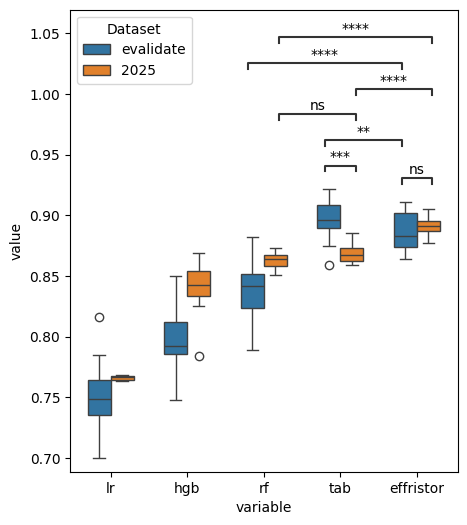

In [3]:
_df1 = roc_auc_score_results.T.melt()
_df1['dataset'] = 'evalidate'

_df2 = roc_auc_score_results_2025.T.melt()
_df2['dataset'] = '2025'

combined_df = pd.concat([_df1, _df2], ignore_index=True)

plt.figure(figsize=(5, 6))

ax = sns.boxplot(x='variable', y='value', hue='dataset', data=combined_df, width=0.6)

pairs=[
    (("rf", "evalidate"), ("effristor", "evalidate")),
    (("tab", "evalidate"), ("effristor", "evalidate")),
    (("rf", "2025"), ("effristor", "2025")),
    (("rf", "2025"), ("tab", "2025")),
    (("tab", "2025"), ("effristor", "2025")),
    (("tab", "evalidate"), ("tab", "2025")),
    (("effristor", "evalidate"), ("effristor", "2025")),
]
annotator = Annotator(ax, pairs, data=combined_df, x="variable", y="value", hue='dataset')
annotator.configure(test='Wilcoxon', text_format='star')
annotator.apply_and_annotate()

display((
    combined_df.groupby(['variable', 'dataset'])['value']
      .agg(['mean', 'std'])
      .reset_index()
))

plt.legend(title='Dataset')
plt.savefig("{}.pdf".format("method_compare"), format="pdf", bbox_inches="tight")
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

tab vs. effristor: Wilcoxon test (paired samples), P_val:6.104e-05 Stat=0.000e+00


,Group,mean,std
0,effristor,-0.004104,0.017633
1,tab,0.026597,0.016505


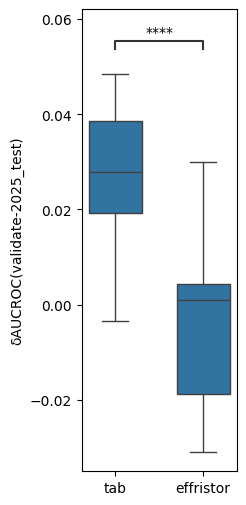

In [4]:
_combined_df_tab_evalidate = combined_df[(combined_df["variable"] == "tab")&(combined_df["dataset"] == "evalidate")]
_combined_df_tab_2025 = combined_df[(combined_df["variable"] == "tab")&(combined_df["dataset"] == "2025")]
_combined_df_effristor_evalidate = combined_df[(combined_df["variable"] == "effristor")&(combined_df["dataset"] == "evalidate")]
_combined_df_effristor_2025 = combined_df[(combined_df["variable"] == "effristor")&(combined_df["dataset"] == "2025")]

_diff_tab = _combined_df_tab_evalidate["value"].values - _combined_df_tab_2025["value"].values
_diff_effristor = _combined_df_effristor_evalidate["value"].values - _combined_df_effristor_2025["value"].values

_df_plot = pd.DataFrame({
    'Difference': list(_diff_tab) + list(_diff_effristor),
    'Group': ['tab'] * len(_diff_tab) + ['effristor'] * len(_diff_effristor)
})

plt.figure(figsize=(2, 6))

ax = sns.boxplot(x='Group', y='Difference', data=_df_plot, width=0.6)

pairs=[("tab", "effristor")]
annotator = Annotator(ax, pairs, data=_df_plot, x="Group", y="Difference")
annotator.configure(test='Wilcoxon', text_format='star')
annotator.apply_and_annotate()

display((
    _df_plot.groupby(['Group'])['Difference']
      .agg(['mean', 'std'])
      .reset_index()
))

plt.xlabel("")
plt.ylabel("δAUCROC(validate-2025_test)")
plt.savefig("{}.pdf".format("overfitting"), format="pdf", bbox_inches="tight")
plt.show()

In [5]:
data = pd.read_excel('../data.xlsx')
data.columns = [col.split(' (')[0] if ":" in col else col for col in data.columns]
data['Normal fertilization'] = data['Normal fertilization'].replace({0: 'abnormal', 1: 'normal'})

interpret_result = pd.read_csv('./interpret_result.csv')
predict_result = pd.read_csv('./benchmark/predictions.2.csv')
predict_result['targets'] = predict_result['targets'].replace({0: 'normal', 1: 'abnormal'})

interpret_result.columns = data.drop(columns=["ID", "Normal fertilization"]).columns
interpret_result["Normal fertilization"] = data["Normal fertilization"]

display(predict_result)
display(interpret_result)

,predictions,targets
0,0.157240,normal
1,0.163337,normal
2,0.157374,normal
3,0.189403,normal
4,0.154904,normal
...,...,...
1228,0.149857,normal
1229,0.139292,normal
1230,0.049657,normal
1231,0.287451,abnormal


,Patient age,Partner age,Previous IVF cycles,Infertility type,Male factors cause infertility,Female factors cause infertility,Years of infertility,Body Mass Index (BMI),Follicle Stimulating Hormone (FSH),Luteinizing hormone (LH),...,Total sperm count before semen optimization treatment (x10^6),Volume after semen optimization treatment,Concentration after semen optimization treatment,PR sperm count after semen optimization treatment,NP sperm count after semen optimization treatment,IM sperm count after semen optimization treatment,Number of oocyte for IVF,Number of oocyte for ICSI,Number of MII oocyte for ICSI,Normal fertilization
0,0.026041,0.013327,-0.000099,0.002072,0.000000,-0.002629,0.000089,0.011352,0.009230,0.001473,...,-0.001675,-0.000006,0.001674,-0.001123,-0.073180,0.003123,-0.706433,0.000000,0.000000,normal
1,0.019635,0.016529,-0.000295,0.000000,0.001288,0.000000,-0.011973,0.022158,0.000858,0.014571,...,0.056559,-0.000235,0.008839,-0.016773,-0.069866,-0.020675,0.000000,-0.385768,-0.159059,normal
2,0.015608,0.023438,0.000275,0.000000,0.000824,0.000000,-0.021815,0.018269,-0.001496,0.003798,...,-0.037418,0.000038,0.013697,0.000328,-0.034963,-0.016252,0.000000,-0.412789,-0.223788,normal
3,0.020831,0.014980,-0.000078,0.000235,0.000398,-0.004239,-0.006880,0.015687,-0.014393,-0.009519,...,-0.023218,0.000001,0.034235,-0.006853,-0.087743,-0.087147,-0.147718,0.000000,0.000000,normal
4,0.028984,0.042052,-0.000270,0.000000,0.001475,0.000000,0.024140,0.021043,-0.028776,-0.011271,...,0.032308,0.000033,0.003766,0.014280,-0.058894,-0.032461,0.000000,-0.702318,-0.267774,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6158,0.022792,0.016840,0.002257,0.001415,0.000000,-0.001198,0.000081,0.011523,0.012728,0.007473,...,-0.008383,0.000028,0.009969,0.004425,-0.079793,-0.055687,-0.618255,0.000000,0.000000,normal
6159,0.013964,0.020330,0.000062,0.000000,0.000000,-0.004252,-0.016405,0.027329,-0.010629,0.006713,...,0.012683,0.000071,0.036763,0.008798,-0.078949,-0.067981,0.019977,0.000000,0.000000,normal
6160,0.019970,0.012207,0.000039,0.000000,-0.000025,-0.000799,-0.001604,0.008341,0.000481,-0.003859,...,0.075348,-0.000069,0.011129,0.000047,-0.088782,0.006147,-0.244459,0.000000,0.000000,normal
6161,0.026678,0.034601,-0.000889,0.000000,0.000000,-0.005185,0.000018,-0.064187,-0.002092,-0.019518,...,0.000035,0.000057,-0.020243,0.014517,0.022882,-0.268826,0.170141,0.000000,0.000000,normal


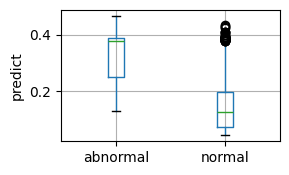

In [6]:
boxplot = predict_result.boxplot(column=["predictions"], by="targets", figsize=(3, 2))

plt.suptitle('')
plt.title('')
plt.xlabel('')
plt.ylabel('predict')
plt.tight_layout()
plt.show()

/home/jin-ya-bin/miniconda3/envs/Effristor/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


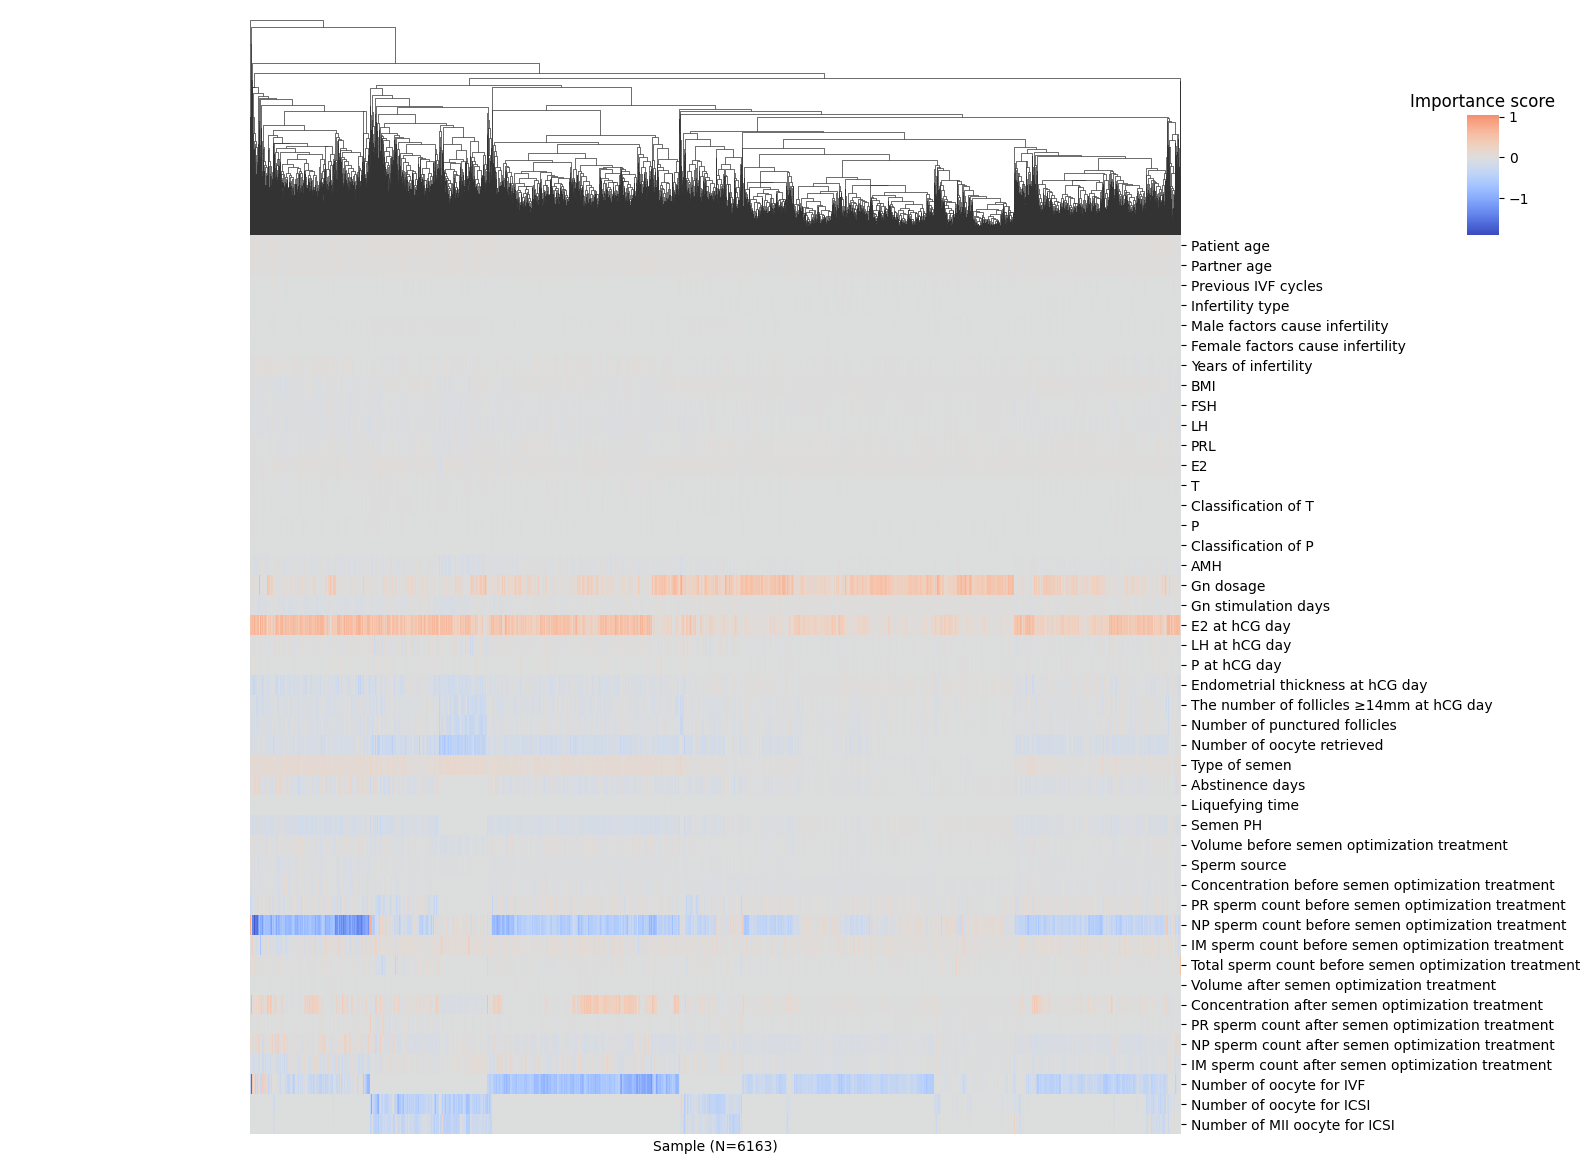

In [7]:
_df = interpret_result.drop(columns=["Normal fertilization"]).copy()
_df = _df.map(lambda x: np.sign(x) * np.log1p(np.abs(x)))
_df = _df.rename(columns={
    "Body Mass Index (BMI)": "BMI",
    "Follicle Stimulating Hormone (FSH)": "FSH",
    "Luteinizing hormone (LH)": "LH",
    "Prolactin (PRL)": "PRL",
    "Estradiol (E2)": "E2",
    "Testosterone (T)": "T",
    "Progesterone (P)": "P",
    "anti-Müllerian hormone (AMH)": "AMH",
    "Gonadotropin (Gn) dosage": "Gn dosage",
    "PR (Progressive motility) sperm count before semen optimization treatment": "PR sperm count before semen optimization treatment",
    "NP (Non-progressive motility) sperm count before semen optimization treatment": "NP sperm count before semen optimization treatment",
    "IM (Immotile) sperm count before semen optimization treatment": "IM sperm count before semen optimization treatment",
    "Total sperm count before semen optimization treatment (x10^6)": "Total sperm count before semen optimization treatment",
})

g = sns.clustermap(
    data=_df.T.fillna(0), cmap='coolwarm', center=0, figsize=(16, 12), row_cluster=False,
    cbar_pos=(0.92, 0.8, 0.02, 0.1),
    # cbar_kws={'label': 'Importance score'},
    # col_colors=_colors,
    # yticklabels=False
)
g.ax_cbar.set_title('Importance score')
g.ax_heatmap.set_xlabel('Sample (N={})'.format(_df.shape[0]))
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_xticks([])

plt.savefig("{}.pdf".format("interpret_result"), format="pdf", bbox_inches="tight")
plt.show()

In [8]:
_df = interpret_result.drop(columns=["Normal fertilization"]).copy()
_df = _df.abs()
_df = _df.div(_df.sum(axis=1), axis=0)
print(_df.mean().sort_values(ascending=False).to_string())

NP (Non-progressive motility) sperm count before semen optimization treatment    0.158370
Number of oocyte for IVF                                                         0.146744
E2 at hCG day                                                                    0.137273
Gonadotropin (Gn) dosage                                                         0.135752
Number of oocyte retrieved                                                       0.037203
Number of oocyte for ICSI                                                        0.034746
Concentration after semen optimization treatment                                 0.026144
NP sperm count after semen optimization treatment                                0.025268
Semen PH                                                                         0.023489
Number of MII oocyte for ICSI                                                    0.022754
Endometrial thickness at hCG day                                                 0.020122
IM (Immoti

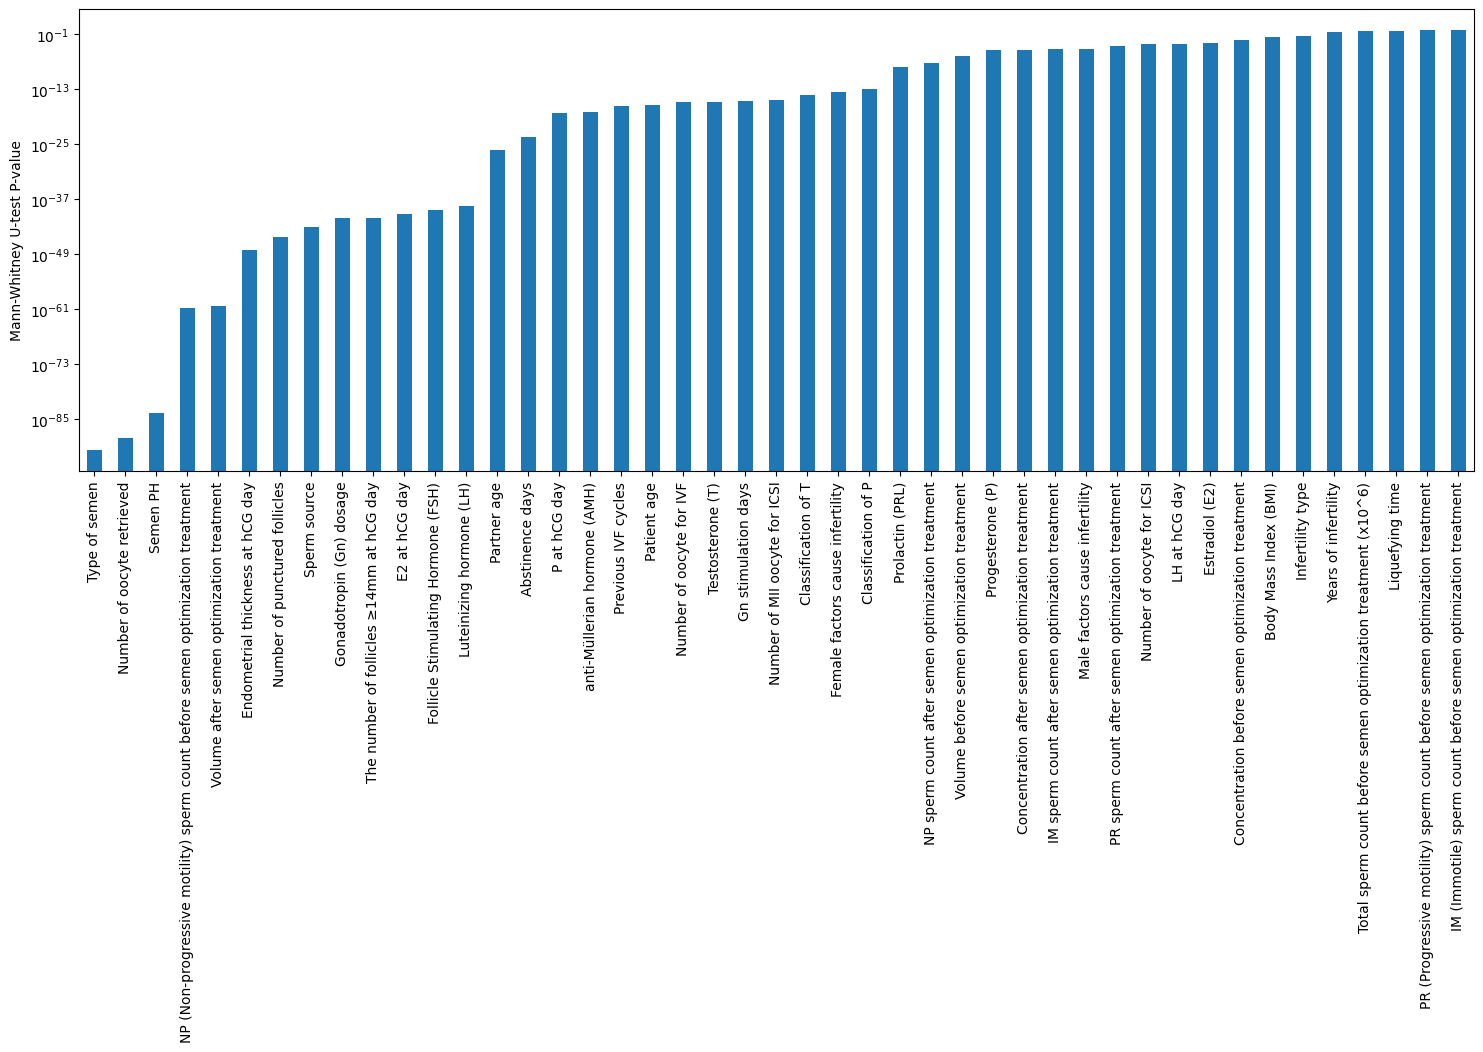

In [9]:
_normal = interpret_result[interpret_result["Normal fertilization"] == 'normal'].drop(columns=["Normal fertilization"])
_abnormal = interpret_result[interpret_result["Normal fertilization"] == 'abnormal'].drop(columns=["Normal fertilization"])

test_result = {}
for column in _normal.columns:
    _normal_clean = _normal[column][~np.isnan(_normal[column])]
    _abnormal_clean = _abnormal[column][~np.isnan(_abnormal[column])]
    u_stat, u_pvalue = mannwhitneyu(_normal_clean, _abnormal_clean, alternative='two-sided')
    
    test_result[column] = [u_pvalue]
test_result = pd.DataFrame(test_result)

ax = test_result.T.sort_values(by=0).plot(kind='bar', figsize=(18, 6), logy=True, legend=False)
plt.ylabel("Mann-Whitney U-test P-value")
plt.show()


In [10]:
suggest_all = {}
for i in range(1, 15):
    suggest_all[i] = pd.read_csv('suggest_{}.csv'.format(i), index_col=0)

,before,1,2,3,4,5,6,7,8,9,10,11,12,13,14
19,0.157074,0.116456,0.116438,0.114840,0.114840,0.109420,0.152467,0.152467,0.118282,0.116572,0.095272,0.095268,0.095239,0.095132,0.092677
22,0.209611,0.102604,0.102591,0.100957,0.143615,0.140760,0.103191,0.103191,0.080320,0.076568,0.153234,0.069302,0.061113,0.075520,0.128792
68,0.189648,0.189648,0.189643,0.188617,0.164960,0.164960,0.180568,0.180568,0.180533,0.185809,0.180302,0.180302,0.180014,0.180301,0.121725
83,0.395258,0.250055,0.241146,0.224672,0.395257,0.370903,0.370861,0.370920,0.328186,0.215339,0.145674,0.156404,0.145831,0.146029,0.139099
93,0.216549,0.216549,0.215438,0.207503,0.207502,0.124001,0.123999,0.123999,0.106812,0.105463,0.099548,0.099549,0.099550,0.099549,0.084378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6122,0.382397,0.207619,0.204486,0.204607,0.204607,0.203208,0.181160,0.181159,0.170968,0.158772,0.148621,0.165921,0.165851,0.165787,0.149067
6143,0.404077,0.235951,0.221622,0.207164,0.404076,0.404076,0.384406,0.384417,0.313399,0.160384,0.159723,0.110434,0.162774,0.103176,0.146844
6148,0.376354,0.214680,0.205692,0.200769,0.200769,0.198011,0.185061,0.185045,0.167324,0.149057,0.155916,0.155916,0.155912,0.155899,0.155892
6155,0.295040,0.247808,0.243927,0.235859,0.235859,0.235110,0.234992,0.234992,0.222975,0.135234,0.064819,0.123584,0.123643,0.134892,0.137199


before    0.328623
1         0.222824
2         0.215550
3         0.202958
4         0.185081
5         0.179421
6         0.177653
7         0.177220
8         0.160996
9         0.136872
10        0.119311
11        0.118062
12        0.117176
13        0.116232
14        0.115843
dtype: float64

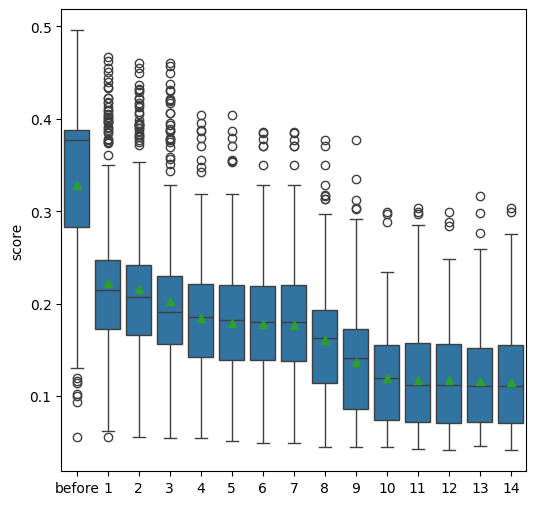

In [11]:
score_df = pd.DataFrame()
for i in range(1, 15):
    _suggest = suggest_all[i].loc["score"]
    _suggest = _suggest.apply(ast.literal_eval)
    _suggest = pd.DataFrame(_suggest.tolist(), index=_suggest.index, columns=["before_{}".format(i), i])
    score_df = pd.concat([score_df, _suggest], axis=1)
score_df = score_df[["before_1"] + [i for i in range(1, 15)]]
score_df.columns = ["before"] + [i for i in range(1, 15)]
display(score_df)

plt.figure(figsize=(6, 6))
_melt_suggest = pd.melt(score_df, var_name='type', value_name='value')
ax = sns.boxplot(x='type', y='value', data=_melt_suggest, showmeans=True)

# pairs=[("before", 1), (1, 2), (2, 4), (4, 7), (7, 14)]
# annotator = Annotator(ax, pairs, data=_melt_suggest, x="type", y="value")
# annotator.configure(test='Wilcoxon', text_format='star')
# annotator.apply_and_annotate()
display(score_df.mean())

ax.set_xlabel("")
ax.set_ylabel("score")
plt.savefig("suggest_score_all.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [12]:
suggest = suggest_all[10]

In [13]:
# plot_index = suggest.index.drop("score")
# num_plots = len(plot_index)
# fig, axes = plt.subplots(1, 7, figsize=(2.5 * num_plots, 6))
# for plot_idx, index in enumerate(plot_index):
#     _suggest = suggest.loc[index]
#     _suggest = _suggest[~_suggest.str.contains("nan")]
#     _suggest = _suggest.apply(ast.literal_eval)
#     _suggest = pd.DataFrame(_suggest.tolist(), index=_suggest.index, columns=["before", "after"])
#     _suggest = pd.melt(_suggest, var_name='type', value_name='value')

#     ax = axes[plot_idx]
#     sns.boxplot(x='type', y='value', data=_suggest, ax=ax)

#     pairs=[("before", "after")]
#     annotator = Annotator(ax, pairs, data=_suggest, x="type", y="value")
#     annotator.configure(test='Wilcoxon', text_format='star')
#     annotator.apply_and_annotate()

#     ax.set_xlabel("")
#     ax.set_ylabel(index)

# plt.tight_layout()
# plt.savefig("suggest_feature_diff_10.pdf", format="pdf", bbox_inches="tight")
# plt.show()

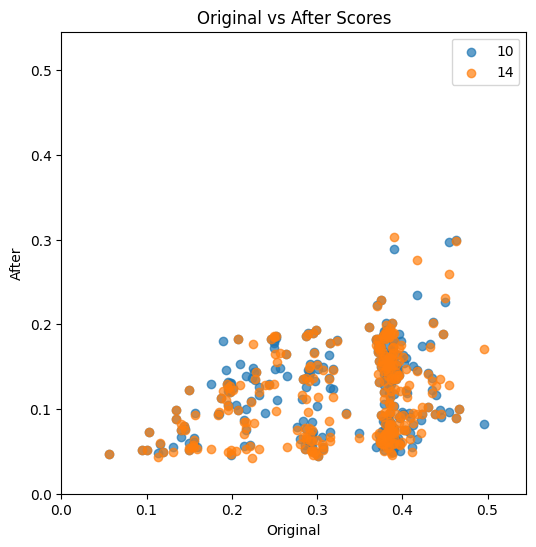

In [14]:
suggest_10 = suggest_all[10].loc["score"]
suggest_10 = suggest_10[~suggest_10.str.contains("nan")]
suggest_10 = suggest_10.apply(ast.literal_eval)
df_10 = pd.DataFrame(suggest_10.tolist(), index=suggest_10.index, columns=["before", "after"])

suggest_14 = suggest_all[14].loc["score"]
suggest_14 = suggest_14[~suggest_14.str.contains("nan")]
suggest_14 = suggest_14.apply(ast.literal_eval)
df_14 = pd.DataFrame(suggest_14.tolist(), index=suggest_14.index, columns=["before", "after"])

plt.figure(figsize=(6, 6))

plt.scatter(df_10['before'], df_10['after'], label='10', alpha=0.7)
plt.scatter(df_14['before'], df_14['after'], label='14', alpha=0.7)

max_val_10 = df_10.max().max()
max_val_14 = df_14.max().max()
max_overall_val = max(max_val_10, max_val_14)

plt.xlim(0, max_overall_val * 1.1)
plt.ylim(0, max_overall_val * 1.1)

plt.xlabel('Original')
plt.ylabel('After')
plt.title('Original vs After Scores')
plt.legend()
plt.savefig("suggest_score_diff.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [15]:
changed_value = pd.DataFrame(
    [
        [int(index), value[0] - value[1]]
        for index, value in suggest.loc["score"].apply(ast.literal_eval).items()
    ],
    columns=["index", "diff"],
)
cut_value = changed_value["diff"].quantile(0.05)

ivf_success_sample = data[data["Normal fertilization"] == "normal"].copy()
suggest_failed_sample = data[data["ID"].isin(changed_value[changed_value["diff"] <= cut_value]["index"].to_list())].copy()
suggest_success_sample = data[data["ID"].isin(changed_value[changed_value["diff"] > cut_value]["index"].to_list())].copy()

ivf success vs. suggest failed: Mann-Whitney-Wilcoxon test two-sided, P_val:1.282e-01 U_stat=5.402e+04
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:1.727e-04 U_stat=8.825e+02
ivf success vs. suggest failed: Mann-Whitney-Wilcoxon test two-sided, P_val:2.122e-01 U_stat=5.222e+04
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:2.781e-03 U_stat=1.126e+03
ivf success vs. suggest failed: Mann-Whitney-Wilcoxon test two-sided, P_val:3.146e-01 U_stat=3.882e+04
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:3.847e-02 U_stat=1.443e+03
ivf success vs. suggest failed: Mann-Whitney-Wilcoxon test two-sided, P_val:2.865e-02 U_stat=5.643e+04
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:1.440e-02 U_stat=1.409e+03
ivf success vs. suggest failed: Mann-Whitney-Wilcoxon test two-sided, P_val:5.870e-01 U_stat=4.712e+04
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon

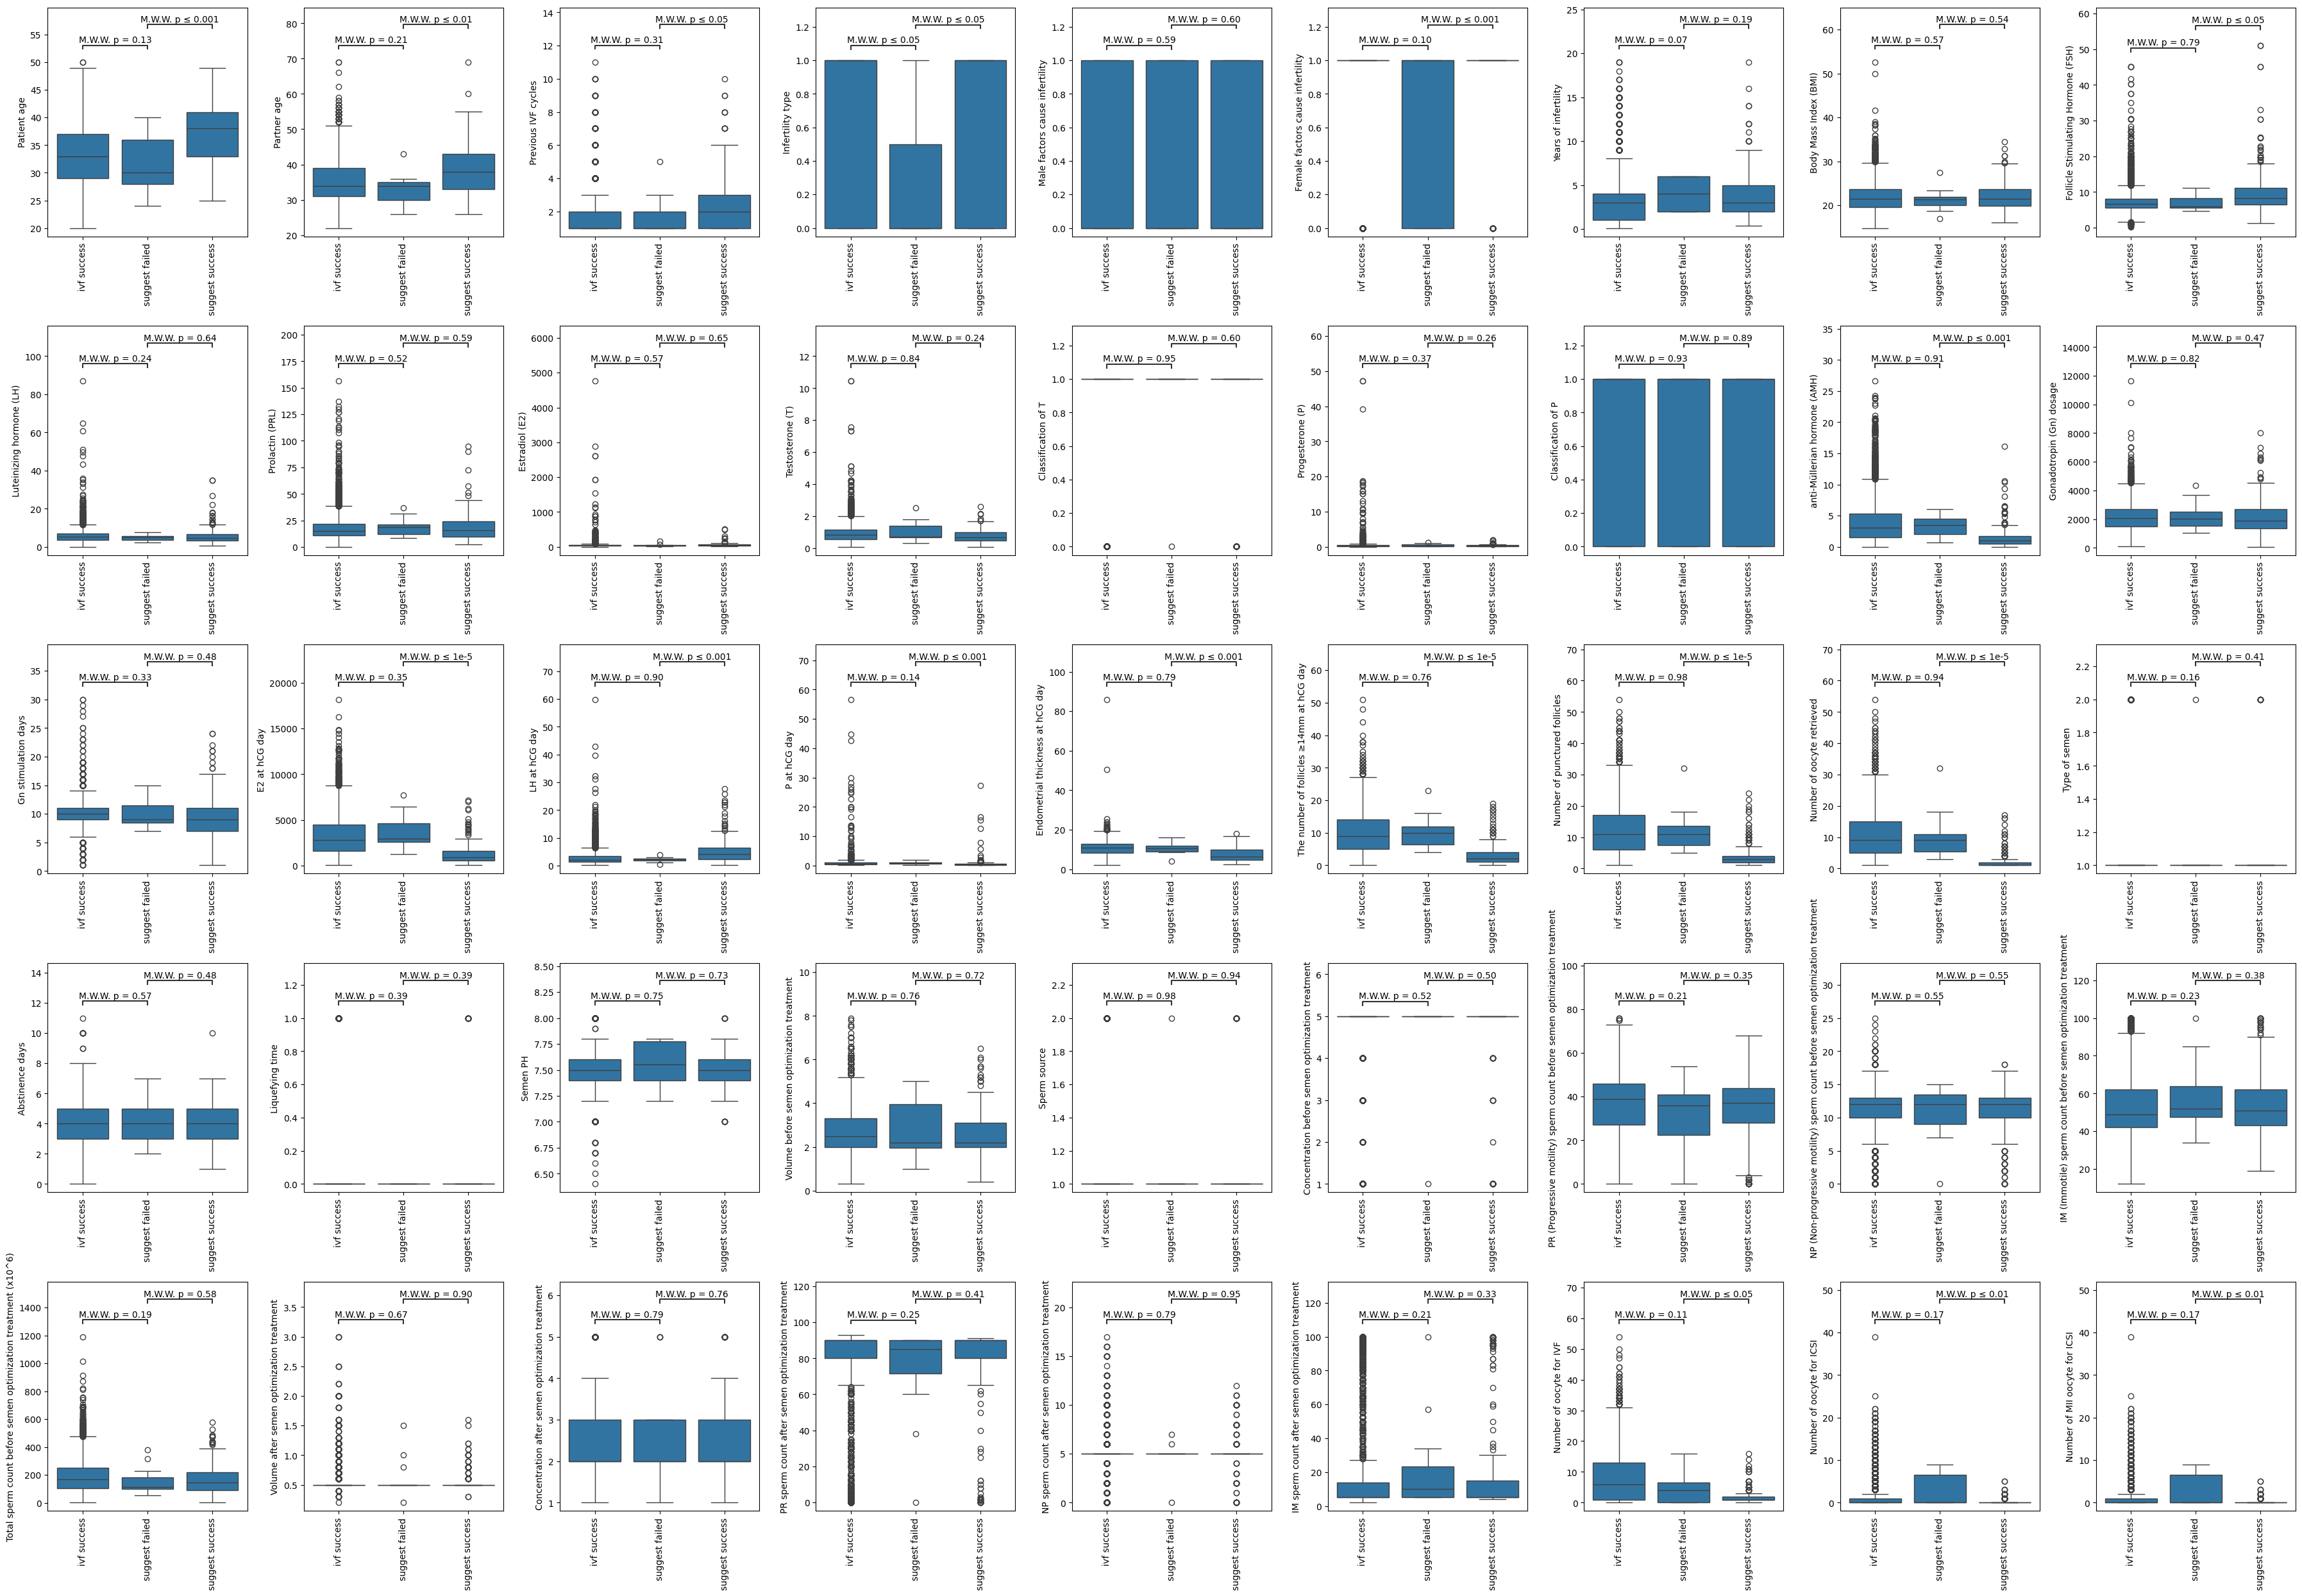

In [16]:
fig, axes = plt.subplots(nrows=5, ncols=9, figsize=(9 * 4, 5 * 5))
axes = axes.flatten()

columns_to_plot = ivf_success_sample.drop(columns=['ID', 'Normal fertilization']).columns
# for index in ["E2 at hCG day", "Gonadotropin (Gn) dosage", "Abstinence days", "Concentration after semen optimization treatment"]:
for i, feature in enumerate(columns_to_plot):
    _ivf_success_data = ivf_success_sample[feature].copy()
    _ivf_success_data.dropna(inplace=True)
    _suggest_failed_sample = suggest_failed_sample[feature].copy()
    _suggest_failed_sample.dropna(inplace=True)
    _suggest_success_sample = suggest_success_sample[feature].copy()
    _suggest_success_sample.dropna(inplace=True)

    _ivf_success_data = _ivf_success_data.to_frame()
    _ivf_success_data["type"] = "ivf success"
    _suggest_failed_sample = _suggest_failed_sample.to_frame()
    _suggest_failed_sample["type"] = "suggest failed"
    _suggest_success_sample = _suggest_success_sample.to_frame()
    _suggest_success_sample["type"] = "suggest success"

    _df = pd.concat([_ivf_success_data, _suggest_failed_sample, _suggest_success_sample], axis=0)
    _df.columns = ["value", "type"]

    ax = axes[i]
    sns.boxplot(x='type', y='value', data=_df, ax=ax)

    pairs=[("ivf success", "suggest failed"), ("suggest failed", "suggest success")]
    annotator = Annotator(ax, pairs, data=_df, x="type", y="value")
    annotator.configure(test='Mann-Whitney', text_format='simple')
    annotator.apply_and_annotate()

    ax.set_xlabel("")
    ax.set_ylabel(feature)
    ax.tick_params(axis='x', rotation=90)

for j in range(len(columns_to_plot), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:5.319e-05 U_stat=3.269e+03
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:9.867e-07 U_stat=5.100e+02
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:5.009e-06 U_stat=3.103e+03
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:3.090e-01 U_stat=2.402e+03


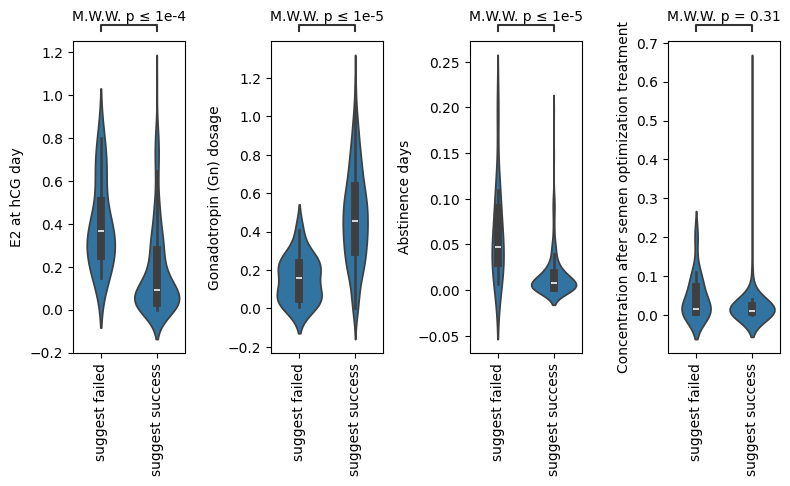

In [17]:
# ivf_success_interpret = interpret_result[interpret_result["Normal fertilization"] == "normal"].copy()
suggest_failed_interpret = interpret_result.loc[data["ID"].isin(changed_value[changed_value["diff"] <= cut_value]["index"].to_list())].copy()
suggest_success_interpret = interpret_result.loc[data["ID"].isin(changed_value[changed_value["diff"] > cut_value]["index"].to_list())].copy()


fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(4 * 2, 1 * 5))
axes = axes.flatten()

columns_to_plot = ["E2 at hCG day", "Gonadotropin (Gn) dosage", "Abstinence days", "Concentration after semen optimization treatment"]
for i, feature in enumerate(columns_to_plot):
    # _ivf_success_interpret = ivf_success_interpret[feature].copy()
    # _ivf_success_interpret.dropna(inplace=True)
    _suggest_failed_sample = suggest_failed_interpret[feature].copy()
    _suggest_failed_sample.dropna(inplace=True)
    _suggest_success_sample = suggest_success_interpret[feature].copy()
    _suggest_success_sample.dropna(inplace=True)

    # _ivf_success_interpret = _ivf_success_interpret.to_frame()
    # _ivf_success_interpret["type"] = "ivf success"
    _suggest_failed_sample = _suggest_failed_sample.to_frame()
    _suggest_failed_sample["type"] = "suggest failed"
    _suggest_success_sample = _suggest_success_sample.to_frame()
    _suggest_success_sample["type"] = "suggest success"

    # _df = pd.concat([_ivf_success_interpret, _suggest_failed_sample, _suggest_success_sample], axis=0)
    _df = pd.concat([_suggest_failed_sample, _suggest_success_sample], axis=0)
    _df.columns = ["value", "type"]
    _df["value"] = _df["value"].abs()

    ax = axes[i]
    sns.violinplot(x='type', y='value', data=_df, ax=ax)

    # pairs=[("ivf success", "suggest failed"), ("suggest failed", "suggest success")]
    pairs=[("suggest failed", "suggest success")]
    annotator = Annotator(ax, pairs, data=_df, x="type", y="value")
    annotator.configure(test='Mann-Whitney', text_format='simple', loc='outside')
    annotator.apply_and_annotate()

    ax.set_xlabel("")
    ax.set_ylabel(feature)
    ax.tick_params(axis='x', rotation=90)

for j in range(len(columns_to_plot), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()